# Classification of wine origin from their chemical properties using a Multilayer Perceptron (PyTorch)

Project created with the help of https://github.com/zankerx

Data from https://datalab-12.ics.uci.edu/dataset/109/wine

Additional Information:

These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines.

The attributes are (dontated by Riccardo Leardi, riclea@anchem.unige.it )
1. Alcohol
2. Malic acid
3. Ash
4. Alcalinity of ash  
5. Magnesium
6. Total phenols
7. Flavanoids
8. Nonflavanoid phenols
9.  Proanthocyanins
10. Color intensity
11. Hue
12. OD280/OD315 of diluted wines
13. Proline 

In a classification context, this is a well posed problem with "well behaved" class structures. A good data set for first testing of a new classifier, but not very challenging.

## Package Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

torch.manual_seed(0) #fix randomness
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Used device:", device)

Used device: cpu


## Dataset Creation

In [2]:
class WineDataset(Dataset):
    def __init__(self, filepath: str):
        # Loading with numpy for simplicity, then convert to torch tensors
        data = np.loadtxt(filepath, delimiter=",", dtype=np.float32)

        # The first column is the class (1, 2 or 3)
        self.labels = torch.tensor(data[:, 0].astype(np.int64) - 1, dtype=torch.long)
        self.features = torch.tensor(data[:, 1:], dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]
    
dataset = WineDataset("./wine/wine.data")

## Dimensions of the dataset

In [3]:
n_labels = torch.unique(dataset.labels).numel()
print("Number of classes:", n_labels)
print("Number of samples in the dataset:", len(dataset))
print("Dimension of the tensor of features:", dataset.features.shape)

Number of classes: 3
Number of samples in the dataset: 178
Dimension of the tensor of features: torch.Size([178, 13])


## Overview of the Dataset with Scatter Plots

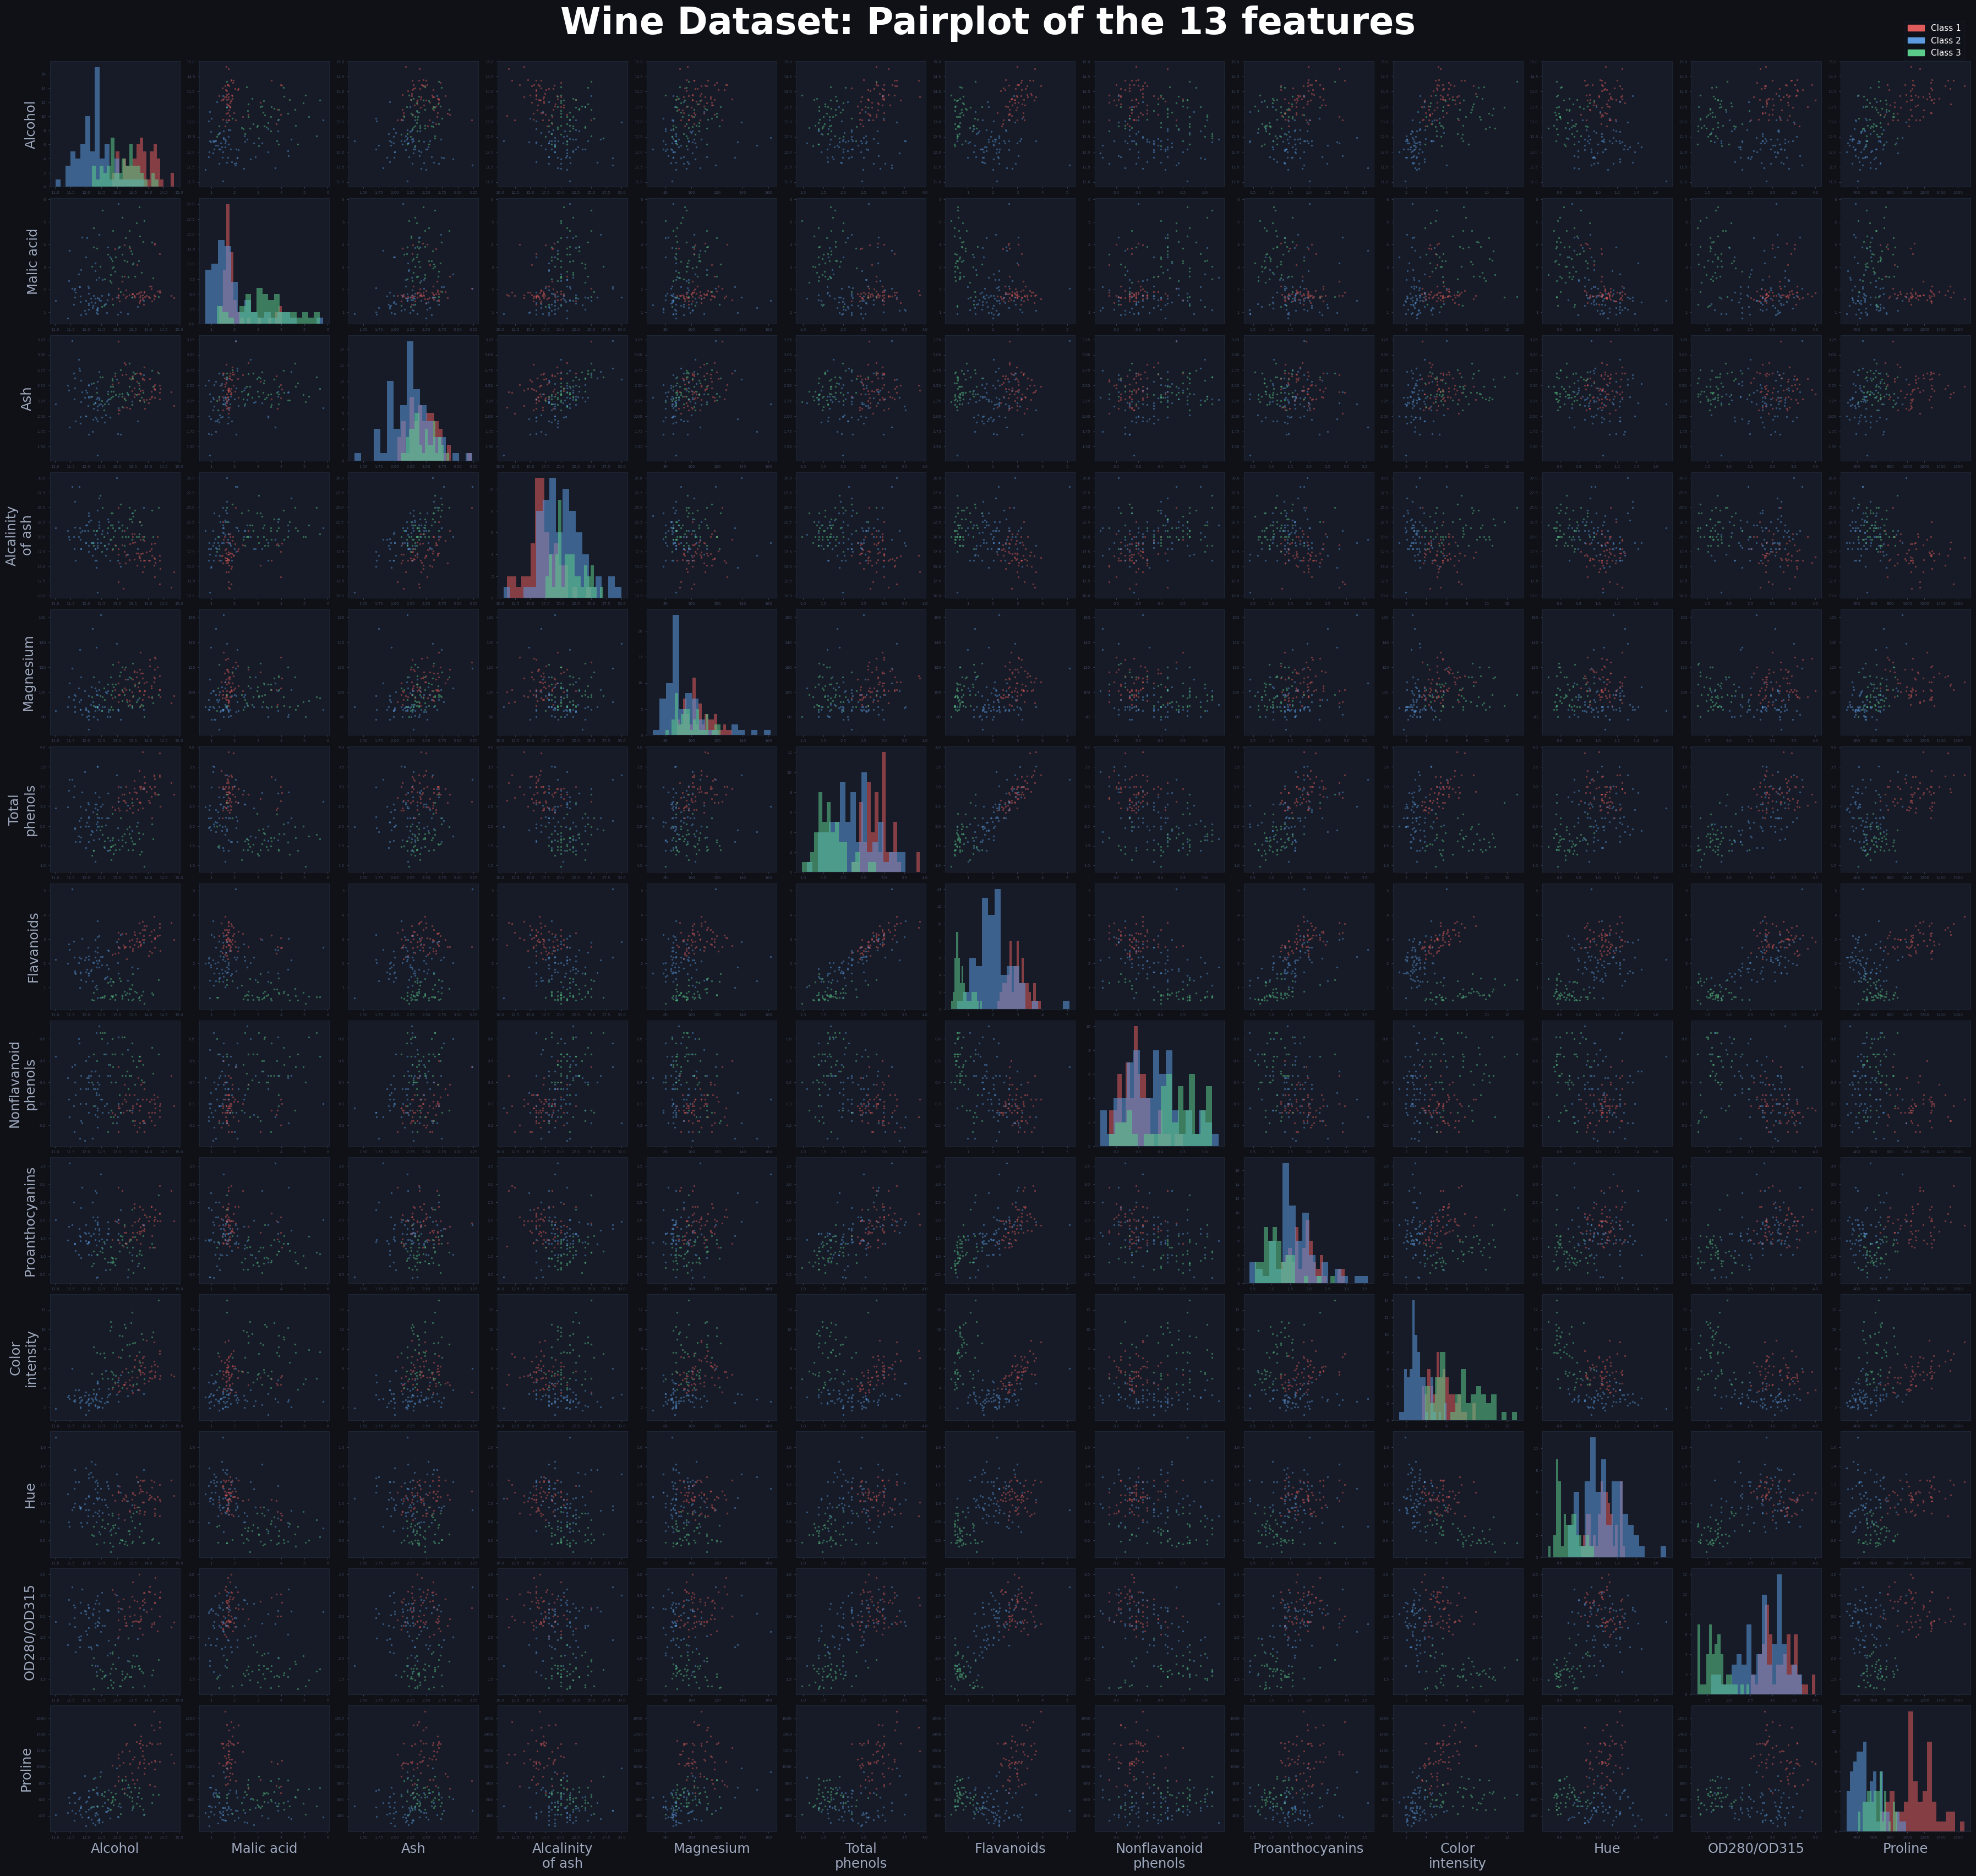

In [4]:
features = dataset.features.numpy()
labels   = (dataset.labels + 1).numpy() # Convert back to 1, 2, 3 for easier plotting

feature_names = [
    "Alcohol", 
    "Malic acid", 
    "Ash", 
    "Alcalinity\nof ash", 
    "Magnesium",
    "Total\nphenols", 
    "Flavanoids", 
    "Nonflavanoid\nphenols", 
    "Proanthocyanins",
    "Color\nintensity", 
    "Hue", 
    "OD280/OD315", 
    "Proline"
]

n = len(feature_names)

# Color of the dots of each group
COLORS = {1: "#e05c5c", 2: "#5c9be0", 3: "#5ccc8a"}
# Transparency of the dots
ALPHA  = 0.45
# Size of the dots
SIZE   = 6

# Definition of the figure and axes
fig, axes = plt.subplots(n, n, figsize=(36, 34))
# Dark background because it's cooler :)
fig.patch.set_facecolor("#0f1117")

# Double loop for each features
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        ax.set_facecolor("#161b27")

        # If it's the same feature, we plot a histogram
        if i == j:
            for cls in [1, 2, 3]:
                mask = labels == cls
                ax.hist(features[mask, i], bins=18, color=COLORS[cls],
                        alpha=0.55, linewidth=0)
                
        # Else, we plot a scatter plot
        else:
            for cls in [1, 2, 3]:
                mask = labels == cls
                ax.scatter(features[mask, j], features[mask, i],
                           c=COLORS[cls], s=SIZE, alpha=ALPHA, linewidths=0)

        # Only the plots on the left and bottom borders have labels, to avoid crowding
        if i == n - 1:
            ax.set_xlabel(feature_names[j], color="#a0aabf", fontsize=17.5, labelpad=4)
        if j == 0:
            ax.set_ylabel(feature_names[i], color="#a0aabf", fontsize=17.5, labelpad=4)

        # Aesthetic adjustments: ticks and spines
        ax.tick_params(colors="#3a4258", labelsize=5, length=2)
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2535")

# Legends
patches = [mpatches.Patch(color=COLORS[c], label=f"Class {c}") for c in [1, 2, 3]]
fig.legend(handles=patches, loc="upper right", bbox_to_anchor=(0.995, 0.995),
           fontsize=11, framealpha=0.15, facecolor="#161b27",
           edgecolor="#3a4258", labelcolor="white")

# Title
fig.suptitle("Wine Dataset: Pairplot of the 13 features", color="white",
             fontsize=48, y=1.001, fontweight="bold")

# Padding between subplots
plt.tight_layout(h_pad=0.4, w_pad=0.4)

# Save the figure
plt.savefig("./images/wine_pairplot.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())

plt.show()

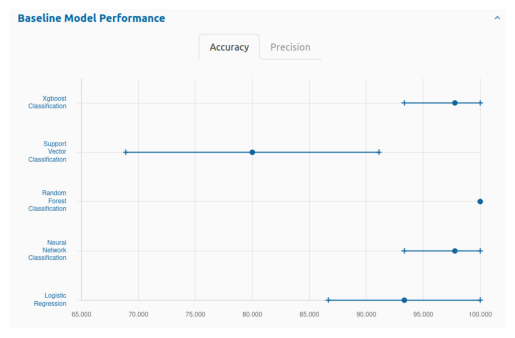

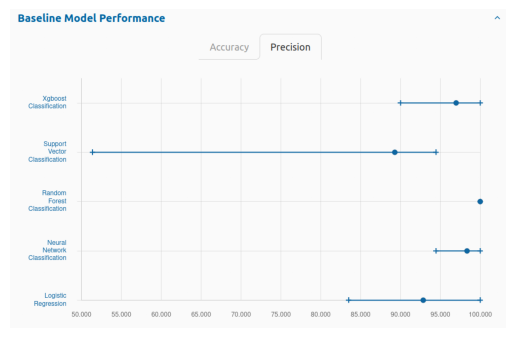

In [5]:
import matplotlib.image as mpimg

img = mpimg.imread("./images/accuracy.png")
plt.imshow(img)
plt.axis("off")
plt.show()

img = mpimg.imread("./images/precision.png")
plt.imshow(img)
plt.axis("off")
plt.show()

In the current case study, we can observe that the Random Forest classifier achieved better performance (Accuracy & Precision) than the neural network-based approach. However, the primary objective of this document is to provide a practical example of how to implement and train a neural network using PyTorch, rather than to identify the optimal predictive model for this specific dataset.

Nevertheless, this example could naturally be extended to more complex datasets involving heterogeneous and non-continuous data types. In such contexts, neural networks may become more appropriate and advantageous than traditional ensemble methods. In particular, neural networks are well suited for:

- learning complex non-linear relationships in high-dimensional spaces,
- integrating multimodal data sources (e.g., continuous variables, categorical features, images, sequences, or graphs),
- automatically extracting hierarchical feature representations without extensive manual feature engineering,
- scaling efficiently to very large datasets,
- enabling transfer learning and representation learning approaches,
- supporting end-to-end differentiable modeling pipelines.

Furthermore, neural architectures offer substantial flexibility for adapting the model structure to the biological or experimental context, for example through convolutional, recurrent, graph-based, or attention-based architectures. Consequently, although Random Forest provided superior results in the present study, neural networks remain highly relevant for future developments involving more diverse, structured, or large-scale datasets.

## Definition of the Multilayer Perceptron Model

We will define the multilayer neural network using the `nn.Module` class from PyTorch.

The model will have:
- an input layer (13 dimensions)
- 2 hidden layers with `ReLU` activation and **dropout** for regularization
- an output layer with 3 dimensions (the number of classes)

In [6]:
class MLP(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_p=0.3):
        # Call the constructor of the parent class (nn.Module)
        super().__init__()
        # Input layer
        self.input_to_layer = nn.Linear(input_dim, hidden_dim)
        # Hidden layers
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        # Output layer
        self.layer_to_output = nn.Linear(hidden_dim, output_dim)
        # Dropout and activation
        self.dropout = nn.Dropout(dropout_p)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.input_to_layer(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.linear1(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.linear2(x)
        x = self.dropout(x)
        x = self.relu(x)
        
        x = self.layer_to_output(x)
        return x

## Initialization of the Hyperparameters

In [ ]:
# Fix the random seed for reproducibility
torch.manual_seed(0) 

# Parameters of the dataset
n_classes = n_labels                    # 3
n_features = dataset.features.shape[1]  # 13
n_samples = len(dataset)                # 178

# Sizes of the mini-batches
batch_size_train = 32
batch_size_test = 64

# Training parameters
learning_rate = 0.005        # learning rate
weight_decay = 0.01          # regularization L2
n_epochs = 500              # number of epochs

# Architecture of the MLP
hidden_dim = 32             # number of neurons in the hidden layers
dropout_p = 0.3             # dropout probability

# Dimensions of the data
input_dim = n_features  # input dim = number of features (13)
output_dim = n_classes  # output dim = number of classes (3)

In [41]:
# Cross-validation split (80% train, 20% test)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

# DataLoaders, which will handle the batching and shuffling of the data during training and testing
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

# Definition of the model
model = MLP(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    dropout_p=dropout_p
)

model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Choice of the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Quick verification to check that everything is working before starting the training loop
# Display a batch to ensure everything is working
X_batch, y_batch = next(iter(train_loader))
print(f"Shape of a batch: {X_batch.shape}, y : {y_batch.shape}")
print(f"Model on device: {next(model.parameters()).device}")


Shape of a batch: torch.Size([32, 13]), y : torch.Size([32])
Model on device: cpu


## Definition of the training function

In [ ]:
def train(model, train_loader, criterion, optimizer, device):
    """
    Do an epoch of trianing on the model
    
    Args:
        model        : le network to train
        train_loader : DataLoader of training data
        criterion    : Loss function
        optimizer    : optimizer
        device       : 'cpu' or 'cuda'
    
    Returns:
        train_loss : mean loss on this epoch
        train_acc  : mean accuracy on this epoch
    """
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()               # 1. Reinitialize the gradients
        outputs = model(X_batch)            # 2. Forward pass
        loss = criterion(outputs, y_batch)  # 3. Compute the loss
        loss.backward()                     # 4. Retropropagation
        optimizer.step()                    # 5. Update the weights

        # Calcul of the loss (accumulated at each batch)
        running_loss += loss.item() * X_batch.size(0)
        # output contains the probability of belonging to each class
        # torch.argmax(outputs, dim=1) is a vector containing the predictions of the most probable class for each sample
        preds = torch.argmax(outputs, dim=1)
        # Compare the predictions with the true labels and count the correct ones
        correct += (preds == y_batch).sum().item()
        # We count the total number of samples processed to calculate the average later
        total += y_batch.size(0)

    # We calculate the mean loss and accuracy over the entire training set
    train_loss = running_loss / total
    train_acc = correct / total
    
    return train_loss, train_acc


## Definition of the evaluation function

In [ ]:
def evaluate(model, data_loader, criterion, device):
    """
    Evaluate the loss and accuracy on a DataLoader (train or test).
    
    Args:
        model       : the model to evaluate
        data_loader : DataLoader
        criterion   : loss function
        device      : 'cpu' or 'cuda'
    
    Returns:
        loss : mean loss
        acc  : mean accuracy
    """
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)              # Forward pass
            loss = criterion(outputs, y_batch)    # Loss calculation
            running_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(outputs, dim=1)  # Class predicted

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    
    loss = running_loss / total
    acc = correct / total

    return loss, acc

## Definition of the run function

In [ ]:
def run(model, train_loader, test_loader, criterion, optimizer, device, n_epochs=100, verbose=True):
    """
    Train the model for n_epochs and return the training metrics.
    
    Args:
        model       : model to train
        train_loader: training DataLoader
        test_loader : test DataLoader
        criterion   : loss function
        optimizer   : optimizer
        device      : 'cpu' or 'cuda'
        n_epochs    : number of epochs
        verbose     : print metrics every 10 epochs if True
    
    Returns:
        train_losses, test_losses, train_accuracies, test_accuracies : lists of metrics
    """
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []

    # For each epoch
    for epoch in range(n_epochs):

        # Train the model for one epoch
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        # And evaluate on the test set
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        # We save the metrics in order to return and plot them later
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        # We print the metrics every 10 epochs if verbose is True
        if verbose and (epoch == 0 or (epoch + 1) % 10 == 0):
            print(f"Epoch {epoch+1}/{n_epochs} "
                  f"- Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} "
                  f"- Train acc: {train_acc*100:.1f}% | Test acc: {test_acc*100:.1f}%")
    
    return train_losses, test_losses, train_accuracies, test_accuracies

## Launch of the training

In [42]:
train_losses, test_losses, train_accuracies, test_accuracies = run(
        model=model, train_loader=train_loader, test_loader=test_loader, criterion=criterion, optimizer=optimizer, device=device, n_epochs=n_epochs, verbose=True
    )

Epoch 1/500 - Train loss: 8.4511 | Test loss: 2.2546 - Train acc: 33.1% | Test acc: 38.9%
Epoch 10/500 - Train loss: 2.5973 | Test loss: 0.9091 - Train acc: 31.0% | Test acc: 50.0%
Epoch 20/500 - Train loss: 1.5587 | Test loss: 1.0665 - Train acc: 39.4% | Test acc: 36.1%
Epoch 30/500 - Train loss: 1.2350 | Test loss: 1.0979 - Train acc: 40.1% | Test acc: 36.1%
Epoch 40/500 - Train loss: 1.2127 | Test loss: 1.0732 - Train acc: 49.3% | Test acc: 36.1%
Epoch 50/500 - Train loss: 1.0668 | Test loss: 1.0817 - Train acc: 45.8% | Test acc: 36.1%
Epoch 60/500 - Train loss: 1.0942 | Test loss: 1.0651 - Train acc: 48.6% | Test acc: 36.1%
Epoch 70/500 - Train loss: 1.0385 | Test loss: 1.0637 - Train acc: 51.4% | Test acc: 36.1%
Epoch 80/500 - Train loss: 1.0624 | Test loss: 1.0737 - Train acc: 44.4% | Test acc: 36.1%
Epoch 90/500 - Train loss: 1.0422 | Test loss: 1.0681 - Train acc: 50.7% | Test acc: 36.1%
Epoch 100/500 - Train loss: 0.9838 | Test loss: 1.0442 - Train acc: 52.8% | Test acc: 38.9%

## Visualization of the Learning Process Across Epochs

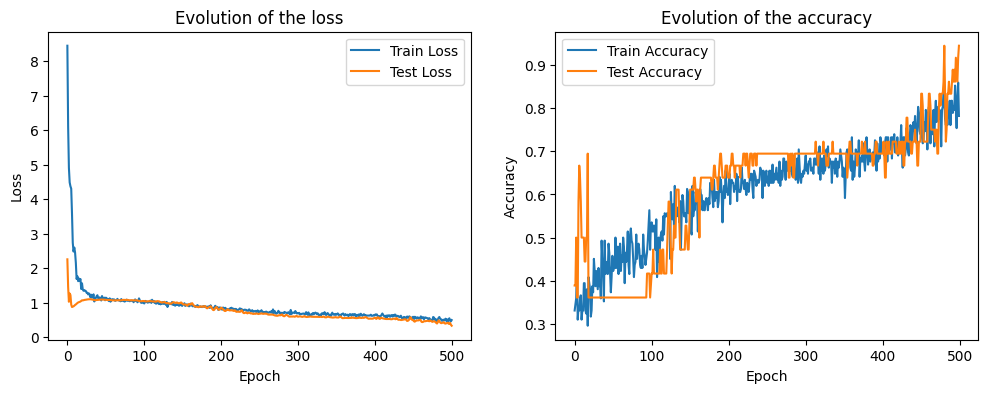

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss function curves
ax[0].plot(train_losses, label="Train Loss")
ax[0].plot(test_losses, label="Test Loss")
ax[0].set_title("Evolution of the loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy curves
ax[1].plot(train_accuracies, label="Train Accuracy")
ax[1].plot(test_accuracies, label="Test Accuracy")
ax[1].set_title("Evolution of the accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.show()


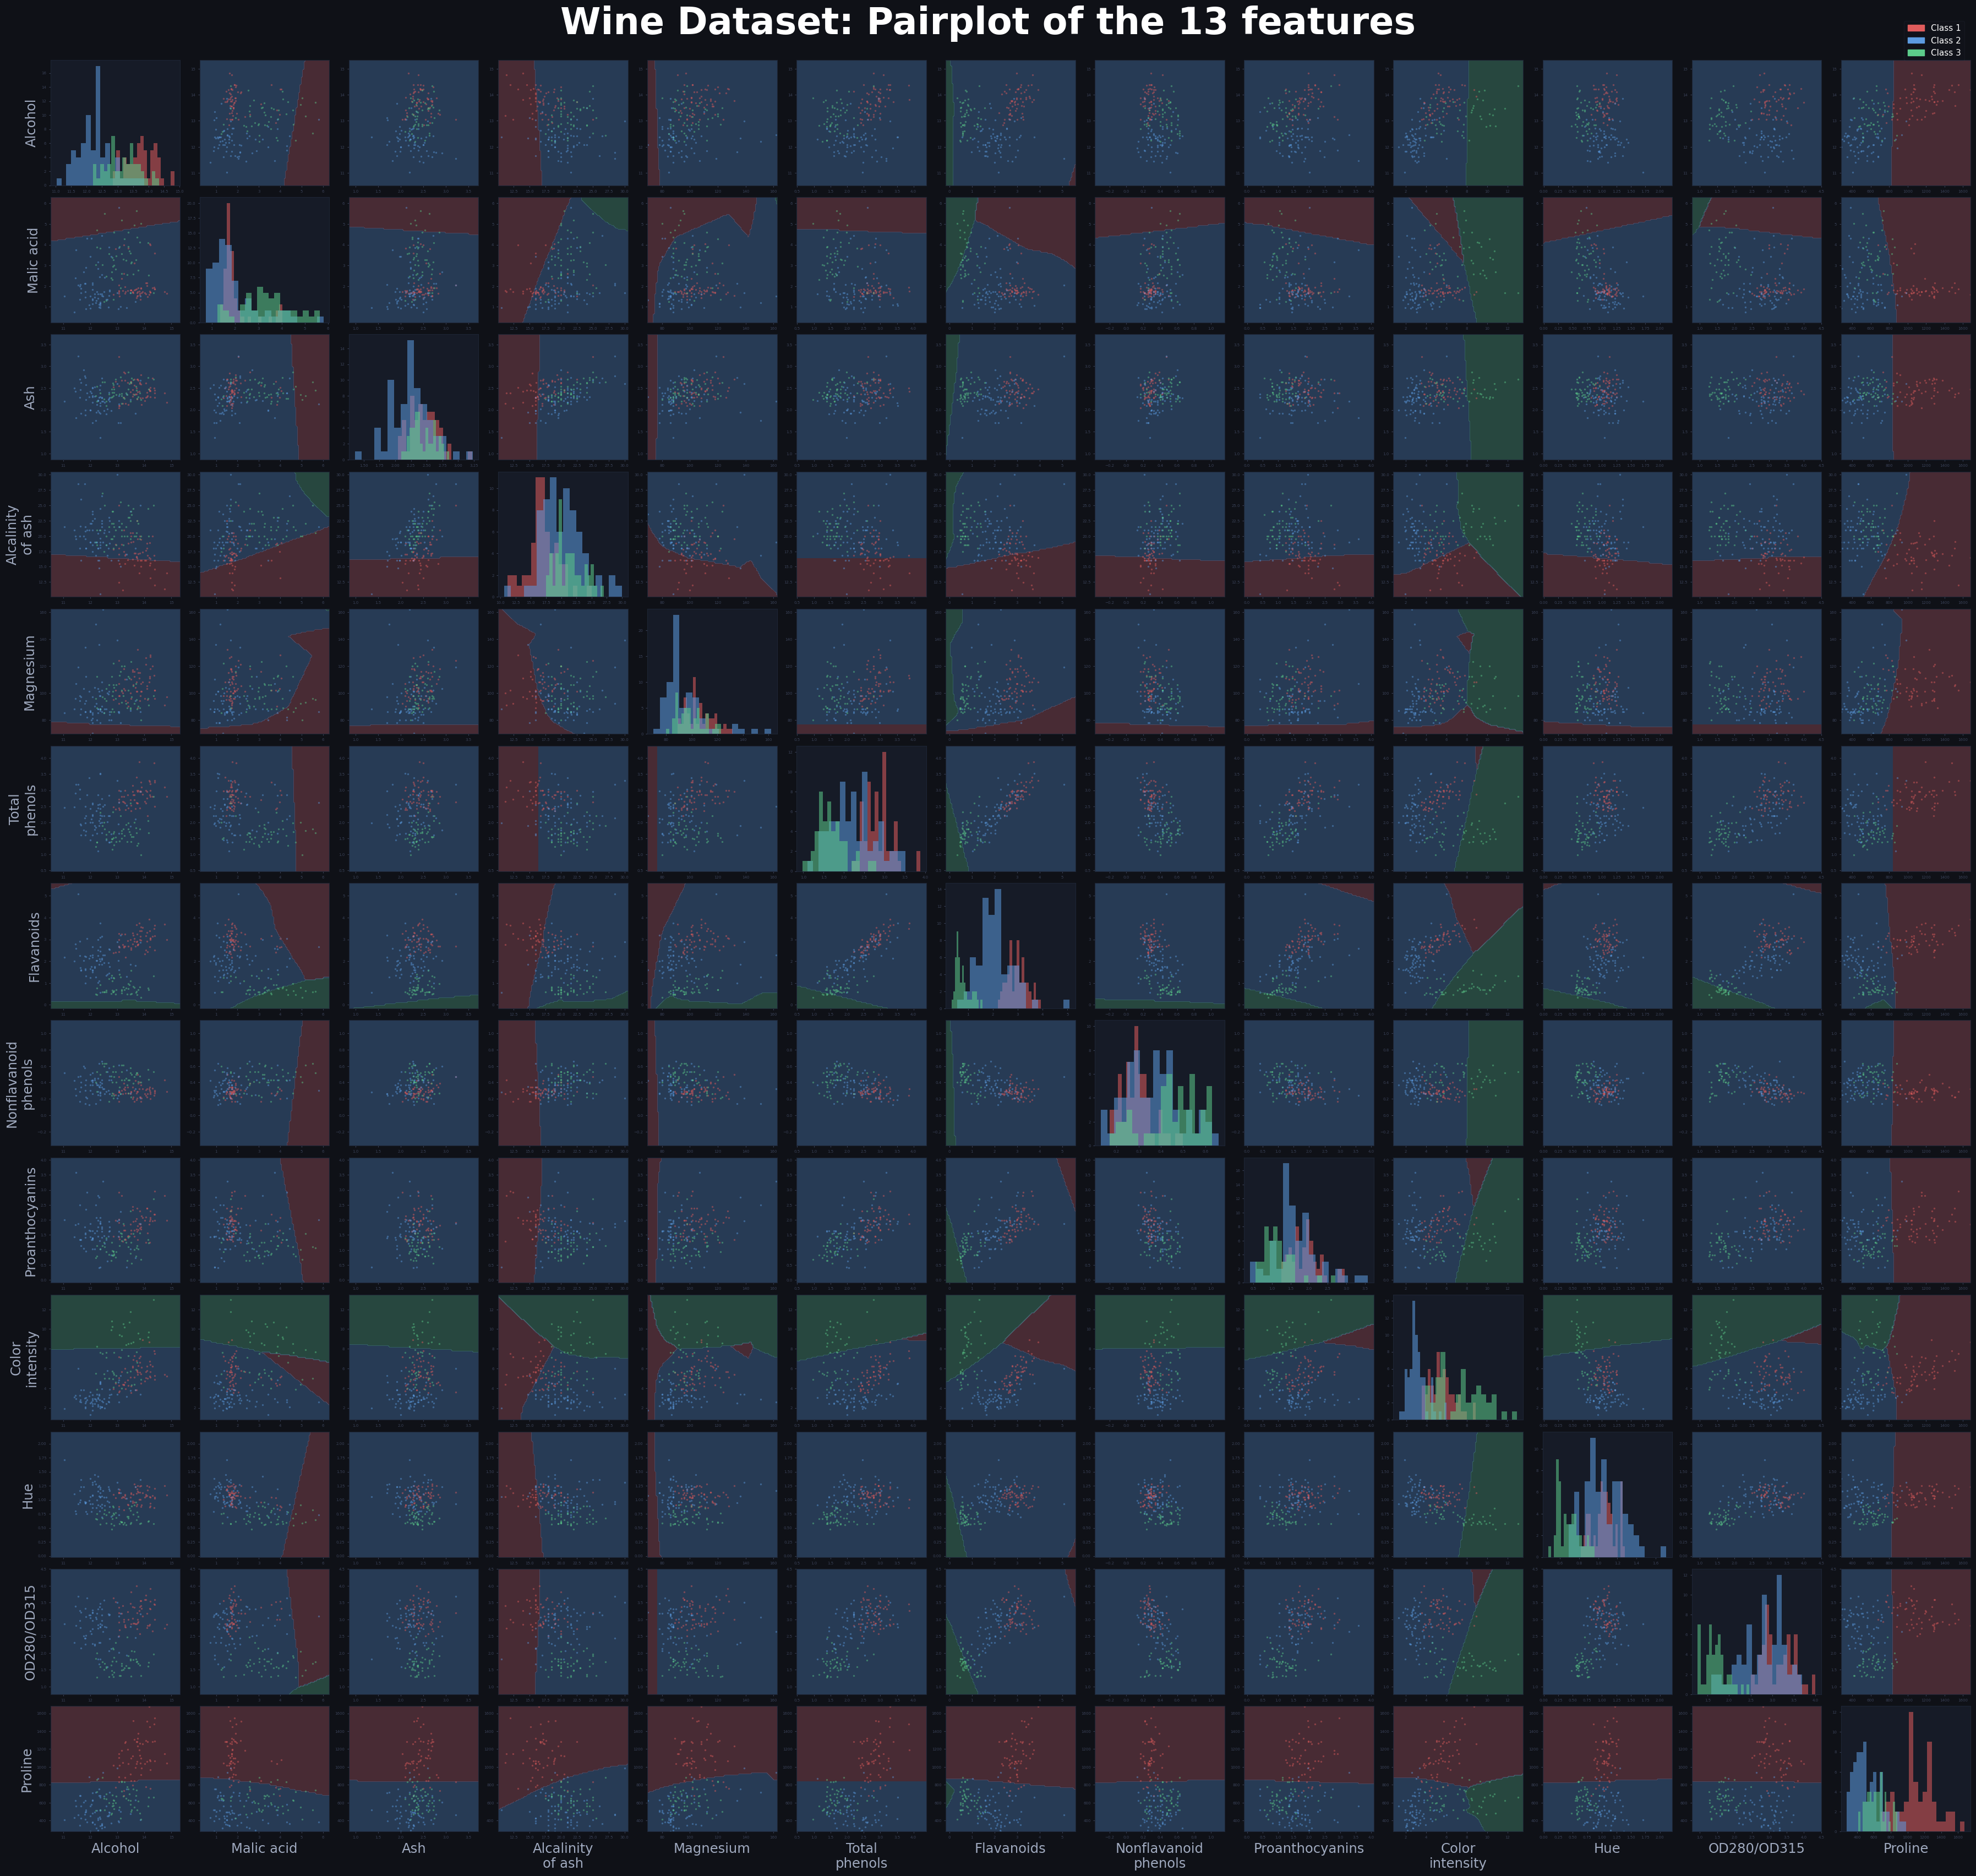

In [ ]:
features = dataset.features.numpy()
labels   = (dataset.labels + 1).numpy()
means    = features.mean(axis=0)  # values fixed for the 11 features that are not plotted in the pairplot (the ones that are not on the axes)

feature_names = [
    "Alcohol", 
    "Malic acid", 
    "Ash", 
    "Alcalinity\nof ash", 
    "Magnesium",
    "Total\nphenols", 
    "Flavanoids", 
    "Nonflavanoid\nphenols", 
    "Proanthocyanins",
    "Color\nintensity", 
    "Hue", 
    "OD280/OD315", 
    "Proline"
]

n = len(feature_names)
COLORS      = {1: "#e05c5c", 2: "#5c9be0", 3: "#5ccc8a"}
CMAP_COLORS = ["#e05c5c", "#5c9be0", "#5ccc8a"]  # même ordre que classes 1, 2, 3
ALPHA       = 0.45
SIZE        = 6

from matplotlib.colors import ListedColormap
cmap_boundary = ListedColormap(CMAP_COLORS)

fig, axes = plt.subplots(n, n, figsize=(36, 34))
fig.patch.set_facecolor("#0f1117")

# We put the model in evaluation mode to disable dropout and other training-specific behaviors
model.eval()

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        ax.set_facecolor("#161b27")

        if i == j:
            for cls in [1, 2, 3]:
                mask = labels == cls
                ax.hist(features[mask, i], bins=18, color=COLORS[cls],
                        alpha=0.55, linewidth=0)
        else:
            # Decision boundary: we create a grid of points and we predict the class for each point to color the background
            x_min, x_max = features[:, j].min() - .5, features[:, j].max() + .5
            y_min, y_max = features[:, i].min() - .5, features[:, i].max() + .5
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                                 np.linspace(y_min, y_max, 100))

            # Grid 13D : everything at the mean except the 2 plotted features
            grid = np.tile(means, (xx.ravel().shape[0], 1))
            grid[:, j] = xx.ravel()  # X axis = feature j
            grid[:, i] = yy.ravel()  # Y axis = feature i

            with torch.no_grad():
                inputs = torch.tensor(grid, dtype=torch.float32)
                preds  = model(inputs).argmax(dim=1).numpy()  # 0, 1, 2

            ax.contourf(xx, yy, preds.reshape(xx.shape),
                        levels=[-0.5, 0.5, 1.5, 2.5],
                        colors=CMAP_COLORS, alpha=0.25)

            # Scatter above the decision boundary
            for cls in [1, 2, 3]:
                mask = labels == cls
                ax.scatter(features[mask, j], features[mask, i],
                           c=COLORS[cls], s=SIZE, alpha=ALPHA, linewidths=0)

        if i == n - 1:
            ax.set_xlabel(feature_names[j], color="#a0aabf", fontsize=17.5, labelpad=4)
        if j == 0:
            ax.set_ylabel(feature_names[i], color="#a0aabf", fontsize=17.5, labelpad=4)

        ax.tick_params(colors="#3a4258", labelsize=5, length=2)
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2535")

# Top-right legend
patches = [mpatches.Patch(color=COLORS[c], label=f"Class {c}") for c in [1, 2, 3]]
fig.legend(handles=patches, loc="upper right", bbox_to_anchor=(0.995, 0.995),
           fontsize=11, framealpha=0.15, facecolor="#161b27",
           edgecolor="#3a4258", labelcolor="white")

# Title
fig.suptitle("Wine Dataset: Pairplot of the 13 features", color="white",
             fontsize=48, y=1.001, fontweight="bold")

# Padding between subplots
plt.tight_layout(h_pad=0.4, w_pad=0.4)

# Save the figure
plt.savefig("./images/wine_pairplot_boundary.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## Hyperparameter Sampling
Let's explore the influence of a hyperparameter by sampling the effect of learning rate (which represents the step in the gradient descent method).

In [45]:
# Grid Search on the learning rate
start = 0.0001
end = 100 * start
learning_rates = torch.linspace(start, end, 10).tolist()
print("Learning rates to test:", learning_rates)

Learning rates to test: [9.999999747378752e-05, 0.0011999999405816197, 0.002300000051036477, 0.0034000000450760126, 0.0044999998062849045, 0.00559999980032444, 0.0066999997943639755, 0.007799999788403511, 0.008899999782443047, 0.009999999776482582]


In [46]:
# Definition of the model
model = MLP(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    dropout_p=dropout_p
)

model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Choice of the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Quick verification to check that everything is working before starting the training loop
# Display a batch to ensure everything is working
X_batch, y_batch = next(iter(train_loader))

In [49]:
import copy

# Dictionary to store the results
results_train_loss = {}
results_test_loss = {}
results_train_acc = {}
results_test_acc = {}

# Loop on the learning rates
for lr in learning_rates:
    print(f"\n=== Learning rate = {lr:.4f} ===")
    
    # Create a new model for each run to avoid reusing weights
    model_copy = copy.deepcopy(model)  # Assurez-vous que 'model' est défini comme base
    model_copy = model_copy.to(device)
    
    # Create an optimizer with the current learning rate
    optimizer = torch.optim.Adam(model_copy.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Train the model
    train_losses, test_losses, train_accuracies, test_accuracies = run(
        model_copy, train_loader, test_loader, criterion, optimizer, device, n_epochs=n_epochs, verbose=False
    )
    
    # Store the results
    results_train_loss[lr] = train_losses
    results_test_loss[lr] = test_losses
    results_train_acc[lr] = train_accuracies
    results_test_acc[lr] = test_accuracies



=== Learning rate = 0.0001 ===

=== Learning rate = 0.0012 ===

=== Learning rate = 0.0023 ===

=== Learning rate = 0.0034 ===

=== Learning rate = 0.0045 ===

=== Learning rate = 0.0056 ===

=== Learning rate = 0.0067 ===

=== Learning rate = 0.0078 ===

=== Learning rate = 0.0089 ===

=== Learning rate = 0.0100 ===


  Learning Rate | Best Test Acc | Epoch of Max
---------------------------------------------
         0.0001 |       0.7222 |          390
         0.0012 |       0.7500 |          499
         0.0023 |       0.9722 |          488
         0.0034 |       0.9722 |          490
         0.0045 |       0.9722 |          332
         0.0056 |       0.9722 |          482
         0.0067 |       0.9722 |          486
         0.0078 |       0.7222 |           18
         0.0089 |       0.7500 |          132
         0.0100 |       0.7222 |           13


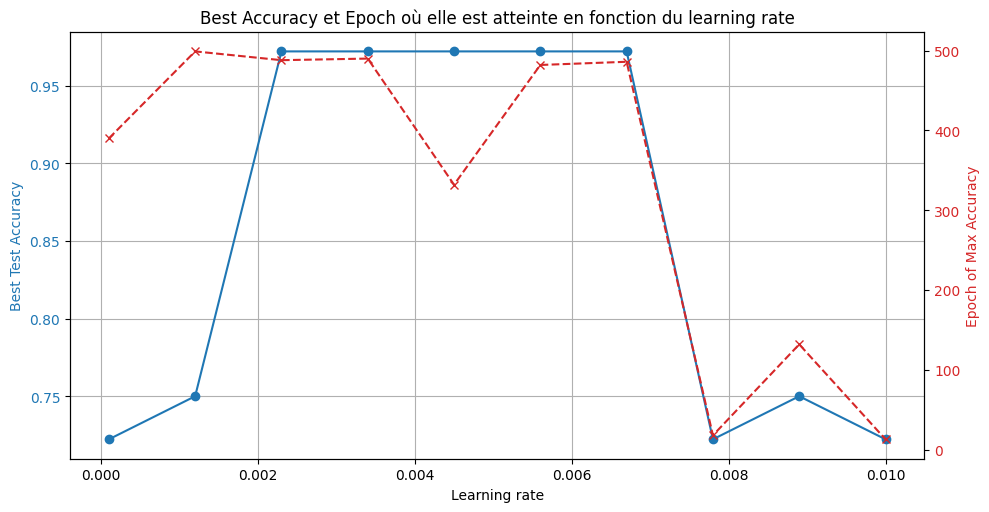

In [ ]:
# Maximum accuracy as a function of the learning rate

#
best_test_acc = []
best_epoch = []

# For each learning rate, we find the maximum test accuracy and the epoch at which it is reached
for lr in learning_rates:
    acc = results_test_acc[lr]
    max_acc = max(acc)
    epoch_max = acc.index(max_acc) + 1  # +1 to count in 1-based
    best_test_acc.append(max_acc)
    best_epoch.append(epoch_max)

# Display the results in a table
print(f"{'Learning Rate':>15} | {'Best Test Acc':>12} | {'Epoch of Max':>12}")
print("-"*45)
for lr, acc, ep in zip(learning_rates, best_test_acc, best_epoch):
    print(f"{lr:15.4f} | {acc:12.4f} | {ep:12d}")

# Plot the results
fig, ax1 = plt.subplots(figsize=(10,5))

# Y-axis on the left for the best test accuracy
color1 = 'tab:blue'
ax1.set_xlabel("Learning rate")
ax1.set_ylabel("Best Test Accuracy", color=color1)
ax1.plot(learning_rates, best_test_acc, marker='o', color=color1, label='Best Test Accuracy')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True)

# Y-axis on the right for the epoch of maximum accuracy
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel("Epoch of Max Accuracy", color=color2)
ax2.plot(learning_rates, best_epoch, marker='x', linestyle='--', color=color2, label='Epoch of Max')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()
plt.title("Best Accuracy et Epoch où elle est atteinte en fonction du learning rate")
plt.show()


We can observe a bell-shaped trend. An interpretation is:
- Low learning rate: the model has not yet reached the asymptote (the model does not seem to be stuck in a local minimum, because the the maximum accuracy is reached at almost 500 epochs but aren't close to 1)
- High learning rate: the model cannot converge to the minima because the parameters of the neural network vary too much.